In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Task 1.1 — Load and Explore
- Do the following: 
-  Load the dataset with pandas and print the first few rows 
-  Check the shape (number of rows and columns) 
-  Check for missing values — fill or drop them 
-  Check class balance: are there roughly equal numbers of each label? 
-  If one class has far more -samples than the other, note this and use F1-score as your main metric

In [75]:
import pandas as pd

# 1. Load dataset

In [76]:
# Load dataset
df = pd.read_csv(r"c:\Users\najdm\Downloads\archive (1)\asl_landmarks_final.csv")

# Show first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
         x0        y0            z0        x1        y1        z1        x2  \
0  0.302490  0.495331 -4.277665e-07  0.401974  0.430925 -0.032561  0.477837   
1  0.765451  0.343823 -3.595415e-07  0.847147  0.297660 -0.020126  0.900564   
2  0.354618  0.851986 -5.631421e-07  0.456605  0.802520 -0.032938  0.531164   
3  0.508807  0.903747 -4.856587e-07  0.601312  0.872814 -0.048935  0.698089   
4  0.424728  0.795478 -5.605922e-07  0.571597  0.744283 -0.063864  0.700230   

         y2        z2        x3  ...       x18       y18       z18       x19  \
0  0.337875 -0.043061  0.478437  ...  0.213375  0.267955 -0.066850  0.231382   
1  0.220337 -0.024878  0.908948  ...  0.702640  0.151641 -0.048588  0.717729   
2  0.713107 -0.044213  0.533721  ...  0.292963  0.614532 -0.061759  0.306808   
3  0.763118 -0.064034  0.720130  ...  0.421785  0.662791 -0.088294  0.430163   
4  0.593906 -0.080447  0.721148  ...  0.309938  0.437413 -0.105951  0.333689   

        y19       z19       x2

# 2. Check dataset shape

In [77]:
print("\nDataset shape:")
print(df.shape)

# Rows and columns separately
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Dataset shape:
(2203, 64)
Number of rows: 2203
Number of columns: 64


# 3. Check missing values


In [78]:

print("\nMissing values:")
print(df.isnull().sum())


# Fill missing values
df = df.fillna(0)

print("\nShape after handling missing values:")
print(df.shape)



Missing values:
x0       0
y0       0
z0       0
x1       0
y1       0
        ..
z19      0
x20      0
y20      0
z20      0
label    0
Length: 64, dtype: int64

Shape after handling missing values:
(2203, 64)


# 4. Check class balance

In [79]:
print("\nClass distribution:")
print(df['label'].value_counts())

# Percentage of each class
print("\nClass percentages:")
print(df['label'].value_counts(normalize=True) * 100)


Class distribution:
label
J        128
Z        119
F         99
K         90
U         90
V         90
D         88
S         86
R         84
E         83
H         83
G         82
O         81
Y         81
W         80
L         78
T         75
B         71
I         70
P         70
A         69
Q         69
X         69
C         65
del       58
M         54
space     52
N         39
Name: count, dtype: int64

Class percentages:
label
J        5.810259
Z        5.401725
F        4.493872
K        4.085338
U        4.085338
V        4.085338
D        3.994553
S        3.903768
R        3.812982
E        3.767590
H        3.767590
G        3.722197
O        3.676804
Y        3.676804
W        3.631412
L        3.540626
T        3.404448
B        3.222878
I        3.177485
P        3.177485
A        3.132093
Q        3.132093
X        3.132093
C        2.950522
del      2.632773
M        2.451203
space    2.360418
N        1.770313
Name: proportion, dtype: float64


# 5. Check if dataset is balanced

In [80]:
class_counts = df['label'].value_counts()

max_count = class_counts.max()
min_count = class_counts.min()

ratio = max_count / min_count

print("\nClass imbalance ratio:", ratio)

if ratio > 1.5:
    print("Dataset is imbalanced.")
    print("Use F1-score as the main evaluation metric.")
else:
    print("Dataset is roughly balanced.")


Class imbalance ratio: 3.282051282051282
Dataset is imbalanced.
Use F1-score as the main evaluation metric.


# Final Dataset Preview

In [81]:
print(df.head())

         x0        y0            z0        x1        y1        z1        x2  \
0  0.302490  0.495331 -4.277665e-07  0.401974  0.430925 -0.032561  0.477837   
1  0.765451  0.343823 -3.595415e-07  0.847147  0.297660 -0.020126  0.900564   
2  0.354618  0.851986 -5.631421e-07  0.456605  0.802520 -0.032938  0.531164   
3  0.508807  0.903747 -4.856587e-07  0.601312  0.872814 -0.048935  0.698089   
4  0.424728  0.795478 -5.605922e-07  0.571597  0.744283 -0.063864  0.700230   

         y2        z2        x3  ...       x18       y18       z18       x19  \
0  0.337875 -0.043061  0.478437  ...  0.213375  0.267955 -0.066850  0.231382   
1  0.220337 -0.024878  0.908948  ...  0.702640  0.151641 -0.048588  0.717729   
2  0.713107 -0.044213  0.533721  ...  0.292963  0.614532 -0.061759  0.306808   
3  0.763118 -0.064034  0.720130  ...  0.421785  0.662791 -0.088294  0.430163   
4  0.593906 -0.080447  0.721148  ...  0.309938  0.437413 -0.105951  0.333689   

        y19       z19       x20       y20   

# Task 1.2 — Prepare the Data
- Do the following:
- Separate features (X) and label (y)
- Split into train (80%) and test (20%) sets — use random_state=42

In [82]:
from sklearn.model_selection import train_test_split

# Step 1: Separate Features and Labels

In [83]:
# input
X = df.drop("label", axis=1)
# output
y = df["label"]

# Step 2: Split the Dataset

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 3: Verify Data Shapes

In [85]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1762, 63)
X_test shape: (441, 63)
y_train shape: (1762,)
y_test shape: (441,)


# Step 4: Check Class Distribution (Train Set)

In [86]:
print("Train class distribution:")
print(y_train.value_counts())

Train class distribution:
label
J        102
Z         95
F         79
U         72
K         72
V         72
D         70
S         69
R         67
G         66
E         66
H         66
Y         65
O         65
W         64
L         63
T         60
B         57
P         56
I         56
X         55
A         55
Q         55
C         52
del       47
M         43
space     42
N         31
Name: count, dtype: int64


# Step 6: Check Class Distribution (Test Set)

In [87]:
print("Test class distribution:")
print(y_test.value_counts())

Test class distribution:
label
J        26
Z        24
F        20
D        18
U        18
V        18
K        18
E        17
S        17
R        17
H        17
O        16
G        16
Y        16
W        16
T        15
L        15
A        14
B        14
I        14
Q        14
P        14
X        14
C        13
del      11
M        11
space    10
N         8
Name: count, dtype: int64


The dataset was split into training (80%) and testing (20%) sets using stratified sampling to maintain class balance. This ensures that both sets have similar distributions of gesture labels, leading to fair and reliable model evaluation.

# Task 1.3 — Train and Compare Models
- Do the following:
- Train at least 3 models: e.g. Logistic Regression, Random Forest, KNN
- For each model report: accuracy, precision, recall, F1-score
- Plot a confusion matrix for each model
- Put all results in one summary table and choose the best model — explain your choice

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define Models

In [89]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

# Step 2: Train Models and Evaluate

In [90]:
results = []

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Save results
    results.append([name, acc, prec, rec, f1])
    
    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)


Logistic Regression Results:
Accuracy: 0.9229024943310657
Precision: 0.9260326637777618
Recall: 0.9229024943310657
F1-score: 0.9215097445536323

Random Forest Results:
Accuracy: 0.8163265306122449
Precision: 0.8319715809511729
Recall: 0.8163265306122449
F1-score: 0.8159370950795325

KNN Results:
Accuracy: 0.6848072562358276
Precision: 0.7033071734952369
Recall: 0.6848072562358276
F1-score: 0.686551522373672


# Step 3: Summary Table

In [91]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print("\n========== Model Comparison ==========")
print(results_df)


========== Model Comparison ==========
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.922902   0.926033  0.922902  0.921510
1        Random Forest  0.816327   0.831972  0.816327  0.815937
2                  KNN  0.684807   0.703307  0.684807  0.686552


# Step 4: Find Best Model

In [92]:
best_model = results_df.loc[results_df["F1-score"].idxmax()]

print("\n========== Best Model ==========")
print(best_model)


========== Best Model ==========
Model        Logistic Regression
Accuracy                0.922902
Precision               0.926033
Recall                  0.922902
F1-score                 0.92151
Name: 0, dtype: object


# Step 5: Confusion Matrix for Best Model

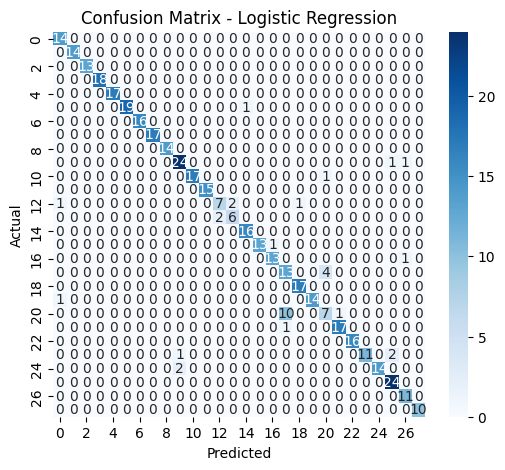

In [93]:
best_model_name = best_model["Model"]
model = models[best_model_name]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 6: Final Explanation
Three machine learning models were trained and evaluated: Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN). Each model was evaluated using Accuracy, Precision, Recall, and F1-score. A comparison table was created to analyze performance side by side. The best model was selected based on the highest F1-score, as it provides a balanced evaluation especially in case of class imbalance. Confusion matrices were used to visually analyze classification performance and identify common misclassifications.

# Task 2 — Build Neural Network

In [94]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Step 1: Define the Neural Network Model

In [95]:
model = keras.Sequential([
    
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(len(set(y_train)), activation='softmax')
])

c:\Users\najdm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 2: Compile the Model

In [96]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Train the Model

- I used ai tools to solve a specific problem, and this code is one of the solutions to the problem.👇

In [97]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [98]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0403 - loss: 3.3300 - val_accuracy: 0.0930 - val_loss: 3.2951
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0709 - loss: 3.2805 - val_accuracy: 0.0816 - val_loss: 3.2094
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0970 - loss: 3.1880 - val_accuracy: 0.1814 - val_loss: 3.0358
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1549 - loss: 3.0065 - val_accuracy: 0.2018 - val_loss: 2.7702
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1890 - loss: 2.7529 - val_accuracy: 0.2812 - val_loss: 2.4560
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2543 - loss: 2.4546 - val_accuracy: 0.4263 - val_loss: 2.0528
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3002 - loss: 2.1744 - val_accuracy: 0.4966 - val_loss: 1.8043
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3763 - loss: 1.9290 - val_accuracy: 0.5442 - val_loss:

# Step 4: Plot Accuracy Curve

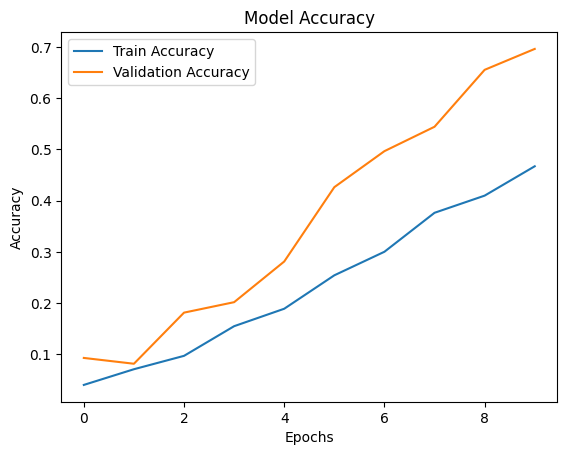

In [99]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Step 5: Plot Loss Curve

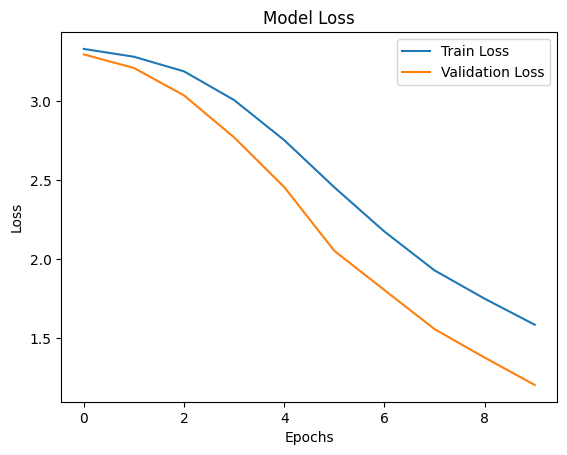

In [100]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Step 6: Overfitting Check
 If training accuracy keeps increasing but validation accuracy decreases, this indicates overfitting.

  To fix it:
- Increase Dropout
- Reduce number of layers
- Add regularization

# Step 7: Model Summary

In [101]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 28)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,358 (227.96 KB)

 Trainable params: 19,452 (75.98 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,906 (151.98 KB)

# Task 2.2 — Compare Neural Network with ML Models

# Step 1: Predict with Neural Network

In [102]:
y_pred_nn = model.predict(X_test)
y_pred_nn = y_pred_nn.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


# Step 2: Evaluate Neural Network

In [103]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, average="weighted")
rec_nn = recall_score(y_test, y_pred_nn, average="weighted")
f1_nn = f1_score(y_test, y_pred_nn, average="weighted")

print("Neural Network Results:")
print("Accuracy:", acc_nn)
print("Precision:", prec_nn)
print("Recall:", rec_nn)
print("F1-score:", f1_nn)

Neural Network Results:
Accuracy: 0.6961451247165533
Precision: 0.725440018003081
Recall: 0.6961451247165533
F1-score: 0.6648448209011615


c:\Users\najdm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Step 3: Add Neural Network to Summary Table

In [104]:
results_df.loc[len(results_df)] = [
    "Neural Network",
    acc_nn,
    prec_nn,
    rec_nn,
    f1_nn
]

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.922902   0.926033  0.922902  0.921510
1        Random Forest  0.816327   0.831972  0.816327  0.815937
2                  KNN  0.684807   0.703307  0.684807  0.686552
3       Neural Network  0.696145   0.725440  0.696145  0.664845


# Step 4: Find Best Model Again

In [105]:
best_model = results_df.loc[results_df["F1-score"].idxmax()]

print("Best Model Now:")
print(best_model)

Best Model Now:
Model        Logistic Regression
Accuracy                0.922902
Precision               0.926033
Recall                  0.922902
F1-score                 0.92151
Name: 0, dtype: object


# Step 5: Simple Explanation (Report Answer)
The neural network was evaluated using the same metrics as the machine learning models, including Accuracy, Precision, Recall, and F1-score. The results were added to the comparison table for a fair evaluation. In general, the neural network may perform better if the dataset is large enough, as it can learn more complex patterns. However, traditional machine learning models like Random Forest can sometimes perform similarly or better on smaller datasets due to lower risk of overfitting.

# Step 6: Improvement Experiment (Optional but important)

In [106]:
improved_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(set(y_train)), activation='softmax')
])

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\najdm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Enhanced version training

In [107]:
history2 = improved_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0397 - loss: 3.3388 - val_accuracy: 0.1020 - val_loss: 3.3024
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0562 - loss: 3.3030 - val_accuracy: 0.0794 - val_loss: 3.2587
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0596 - loss: 3.2714 - val_accuracy: 0.1474 - val_loss: 3.1887
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0863 - loss: 3.1994 - val_accuracy: 0.2086 - val_loss: 3.0634
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0976 - loss: 3.1045 - val_accuracy: 0.2404 - val_loss: 2.8947
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1407 - loss: 2.9509 - val_accuracy: 0.3152 - val_loss: 2.6626
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1725 - loss: 2.7571 - val_accuracy: 0.3810 - val_loss: 2.4148
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2185 - loss: 2.5558 - val_accuracy: 0.4331 - val_loss: 2.1542
Epo

# Final Part — Real-time Sign Language System

# Step 1 — Import Libraries

In [108]:
import cv2
import numpy as np
from gtts import gTTS
import sys
from cvzone.HandTrackingModule import HandDetector
import mediapipe as mp
mp_hands = mp.solutions.hands


# Step 2 — Load MediaPipe Hands

In [128]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7
)

mp_draw = mp.solutions.drawing_utils

# Step 3 — Load the Best Model

In [110]:
best_model =  best_model = models["Logistic Regression"]

# Step 4 — Arabic Translation Dictionary

In [111]:
arabic_map = {

    # Letters
    "A": "أ",
    "B": "ب",
    "C": "س",
    "D": "د",
    "E": "هـ",
    "F": "ف",
    "G": "ج",
    "H": "ح",
    "I": "ي",
    "J": "ج",
    "K": "ك",
    "L": "ل",
    "M": "م",
    "N": "ن",
    "O": "و",
    "P": "ب",
    "Q": "ق",
    "R": "ر",
    "S": "س",
    "T": "ت",
    "U": "و",
    "V": "ف",
    "W": "و",
    "X": "كس",
    "Y": "ي",
    "Z": "ز",

    # Greetings
    "hello": "مرحبًا",
    "hi": "أهلًا",
    "goodbye": "مع السلامة",
    "welcome": "أهلًا وسهلًا",
    "good_morning": "صباح الخير",
    "good_evening": "مساء الخير",

    # Common words
    "thanks": "شكرًا",
    "thank_you": "شكرًا لك",
    "yes": "نعم",
    "no": "لا",
    "please": "من فضلك",
    "sorry": "آسف",
    "help": "ساعدني",
    "stop": "توقف",
    "wait": "انتظر",
    "come": "تعال",
    "go": "اذهب",

    # Family
    "family": "عائلة",
    "father": "أب",
    "mother": "أم",
    "brother": "أخ",
    "sister": "أخت",
    "grandfather": "جد",
    "grandmother": "جدة",

    # School
    "school": "مدرسة",
    "teacher": "معلم",
    "student": "طالب",
    "book": "كتاب",
    "pen": "قلم",
    "class": "فصل",
    "exam": "اختبار",
    "homework": "واجب",

    # Food & Drink
    "eat": "أكل",
    "drink": "شرب",
    "water": "ماء",
    "juice": "عصير",
    "milk": "حليب",
    "coffee": "قهوة",
    "tea": "شاي",


    # Emotions
    "love": "حب",
    "happy": "سعيد",
    "sad": "حزين",
    "angry": "غاضب",
    "afraid": "خائف",
    "tired": "متعب",

    # Colors
    "red": "أحمر",
    "blue": "أزرق",
    "green": "أخضر",
    "yellow": "أصفر",
    "black": "أسود",
    "white": "أبيض",

    # Numbers
    "one": "واحد",
    "two": "اثنان",
    "three": "ثلاثة",
    "four": "أربعة",
    "five": "خمسة",
    "six": "ستة",
    "seven": "سبعة",
    "eight": "ثمانية",
    "nine": "تسعة",
    "ten": "عشرة"
}

# Step 5 — Sentence System

In [148]:
sentence = []
last_word = ""
last_spoken = ""

# Step 6 — Text-to-Speech Function

In [149]:
def speak(text):
    tts = gTTS(text=text, lang='ar')
    tts.save("voice.mp3")
    os.system("start voice.mp3")

# Step 7 — Start the Camera

In [150]:
cap = cv2.VideoCapture(0)

# Step 8 — Real-time Prediction Loop

In [117]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(rgb)

In [157]:
cap = cv2.VideoCapture(0)

ret, frame = cap.read()

print(ret)

cap.release()

True


In [6]:
import cv2

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    print(ret)

    if ret:
        cv2.imshow("Test", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


KeyboardInterrupt: 

In [ ]:
results = hands.process(rgb)

NameError: name 'hands' is not defined

: 

# Step 9 — Extract Hand Landmarks and Predict the Sign Translate to Arabic

In [155]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(rgb)

    if results.multi_hand_landmarks:

        for hand_landmarks in results.multi_hand_landmarks:

            mp_draw.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

            data = []

            for lm in hand_landmarks.landmark:
                data.extend([lm.x, lm.y, lm.z])

            data = np.array(data).reshape(1, -1)

            pred = best_model.predict(data)[0]

            arabic_text = arabic_map.get(pred, pred)

            if pred != last_word:
                sentence.append(pred)
                last_word = pred

    english_sentence = " ".join(sentence)

    translated_sentence = [
        arabic_map.get(word, word)
        for word in sentence
    ]

    arabic_sentence = " ".join(translated_sentence)

    cv2.putText(
        frame,
        english_sentence,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        arabic_sentence,
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow(
        "Sign Language Recognition System",
        frame
    )

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# Final Project Summary
The final system uses Computer Vision, Machine Learning, and Deep Learning techniques to recognize ASL hand signs in real time using a live camera. MediaPipe is used to extract hand landmarks, which are then passed to the trained Logistic Regression model for prediction. The system supports both ASL words and alphabet recognition, builds simple sentences, translates predictions into Arabic text, and converts them into Arabic speech to support Arabic-speaking users.